In [71]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score)

In [72]:
## my input features
alignment_matrix = np.load("./sample_hacking_output_20251003_161559/alignment_matrix_M.npy")

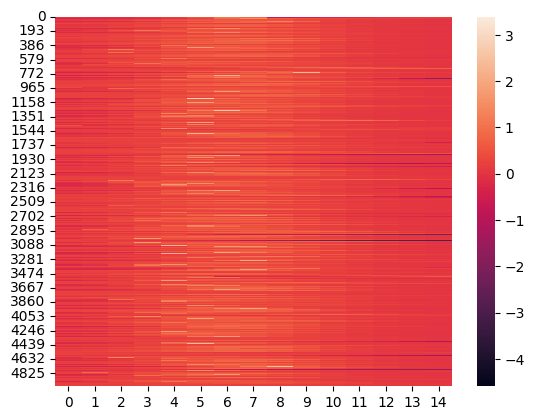

In [73]:
sns.heatmap(alignment_matrix)
plt.show()

In [74]:
## my input features
alignment_matrix = np.load("./sample_hacking_output_20251003_163455/alignment_matrix_M.npy")

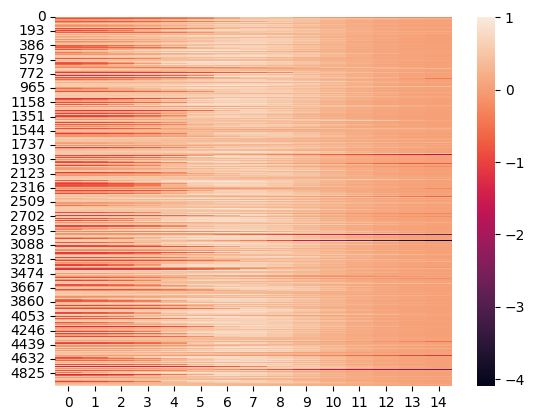

In [75]:
sns.heatmap(alignment_matrix)
plt.show()

In [76]:
with open('./sample_hacking_output_20251003_163455/predictions.json', 'r') as file:
    data = json.load(file)

In [77]:
ground_truth = np.array(data["indicator_vector_true"])

Logistic Regression
SVM (RBF)
Random Forest
Gradient Boosting
Model performance (mean ± std):

Logistic Regression:
  accuracy  : 0.526 ± 0.014
  f1        : 0.612 ± 0.018
  precision : 0.517 ± 0.009
  recall    : 0.750 ± 0.035
  roc_auc   : 0.547 ± 0.016

SVM (RBF):
  accuracy  : 0.570 ± 0.011
  f1        : 0.691 ± 0.007
  precision : 0.540 ± 0.006
  recall    : 0.962 ± 0.011
  roc_auc   : 0.591 ± 0.017

Random Forest:
  accuracy  : 0.547 ± 0.012
  f1        : 0.562 ± 0.011
  precision : 0.544 ± 0.011
  recall    : 0.581 ± 0.012
  roc_auc   : 0.582 ± 0.014

Gradient Boosting:
  accuracy  : 0.571 ± 0.006
  f1        : 0.643 ± 0.008
  precision : 0.551 ± 0.004
  recall    : 0.772 ± 0.016
  roc_auc   : 0.590 ± 0.005

Best model based on ROC AUC: SVM (RBF)


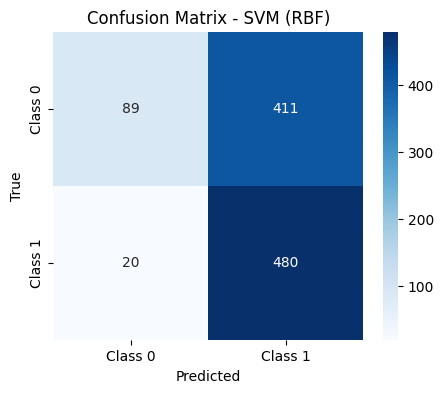


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.18      0.29       500
           1       0.54      0.96      0.69       500

    accuracy                           0.57      1000
   macro avg       0.68      0.57      0.49      1000
weighted avg       0.68      0.57      0.49      1000



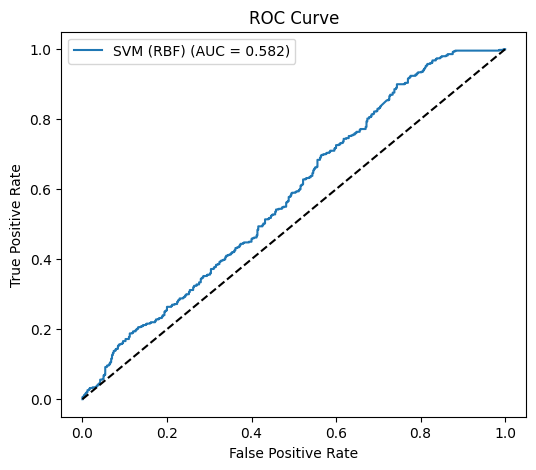

In [82]:
# Define models to try
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    print(name)
    pipe = make_pipeline(StandardScaler(), model)
    scores = cross_validate(pipe, alignment_matrix, ground_truth, cv=cv,
                            scoring=["accuracy", "f1", "precision", "recall", "roc_auc"],
                            return_train_score=False)
    results[name] = {metric: (np.mean(scores[f"test_{metric}"]), np.std(scores[f"test_{metric}"]))
                     for metric in ["accuracy", "f1", "precision", "recall", "roc_auc"]}
    
# Print results
print("Model performance (mean ± std):")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, (mean_val, std_val) in metrics.items():
        print(f"  {metric:10s}: {mean_val:.3f} ± {std_val:.3f}")

# Pick best model by ROC AUC
best_model_name = max(results, key=lambda k: results[k]["roc_auc"][0])
print(f"\nBest model based on ROC AUC: {best_model_name}")

# Train/test split for final eval
X_train, X_test, y_train, y_test = train_test_split(alignment_matrix, ground_truth,
                                                    test_size=0.2, stratify=ground_truth,
                                                    random_state=42)

pipe = make_pipeline(StandardScaler(), models[best_model_name])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()